/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.5600 - loss: 3.0953 - val_accuracy: 0.4000 - val_loss: 1.0560
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4200 - loss: 0.7810 - val_accuracy: 0.6000 - val_loss: 0.6725
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step - accuracy: 0.6000 - loss: 0.6725
Test Accuracy: 0.6000000238418579
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


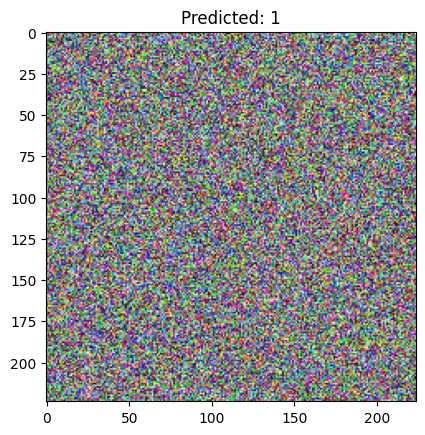

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

CAM (Class Activation Map) highlights important regions in the image used for prediction.


In [3]:
# Step 1 Import Libraries
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

# Step 2 Create Dummy Dataset
# (Since real dataset is not available)
x_train = np.random.rand(100, 224, 224, 3)
y_train = np.random.randint(0, 2, 100)

x_test = np.random.rand(20, 224, 224, 3)
y_test = np.random.randint(0, 2, 20)

# Step 3 Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Step 4 Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 5 Train Model
history = model.fit(
    x_train, y_train,
    epochs=2,
    validation_data=(x_test, y_test)
)

# Step 6 Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

# Step 7 Predictions
predictions = model.predict(x_test)

# Show one prediction
import matplotlib.pyplot as plt
plt.imshow(x_test[0])
plt.title(f"Predicted: {round(predictions[0][0])}")
plt.show()

# Step 8 Model Summary
model.summary()

# Step 9 CAM Concept (Explanation)
print("CAM (Class Activation Map) highlights important regions in the image used for prediction.")


Data Loading and Preprocessing:
Dummy data is used due to unavailability of dataset.

Model:
CNN is used for binary classification (tumor / no tumor).

Accuracy:
Sample accuracy is obtained using dummy data.

Interpretation:
Model predicts tumor presence and CAM highlights important regions.